# Data storytelling notebook 3/3
Purpose: Tell the story of the mood changes in music with the seasons globaly.
Dataset: Using our `silver_spotify_daily`-table that spans from 2023/10-18 - 2025-06-11

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
# Konstanter
DB_PATH = "../data/music_warehouse.duckdb"

# Uppkoppling mot DB
con = duckdb.connect(DB_PATH)

In [2]:
# Göra en query för att hämta snitt-glädjen(VALENCE) per vecka
query_mood = """
SELECT  
    date_trunc('week', CAST(snapshot_date AS DATE)) AS week,
    AVG(valence) AS avg_valence,
    AVG(danceability) AS avg_danceability
FROM silver_spotify_daily
GROUP BY 1
ORDER BY 1
"""

df_mood = con.execute(query_mood).df()
con.close()

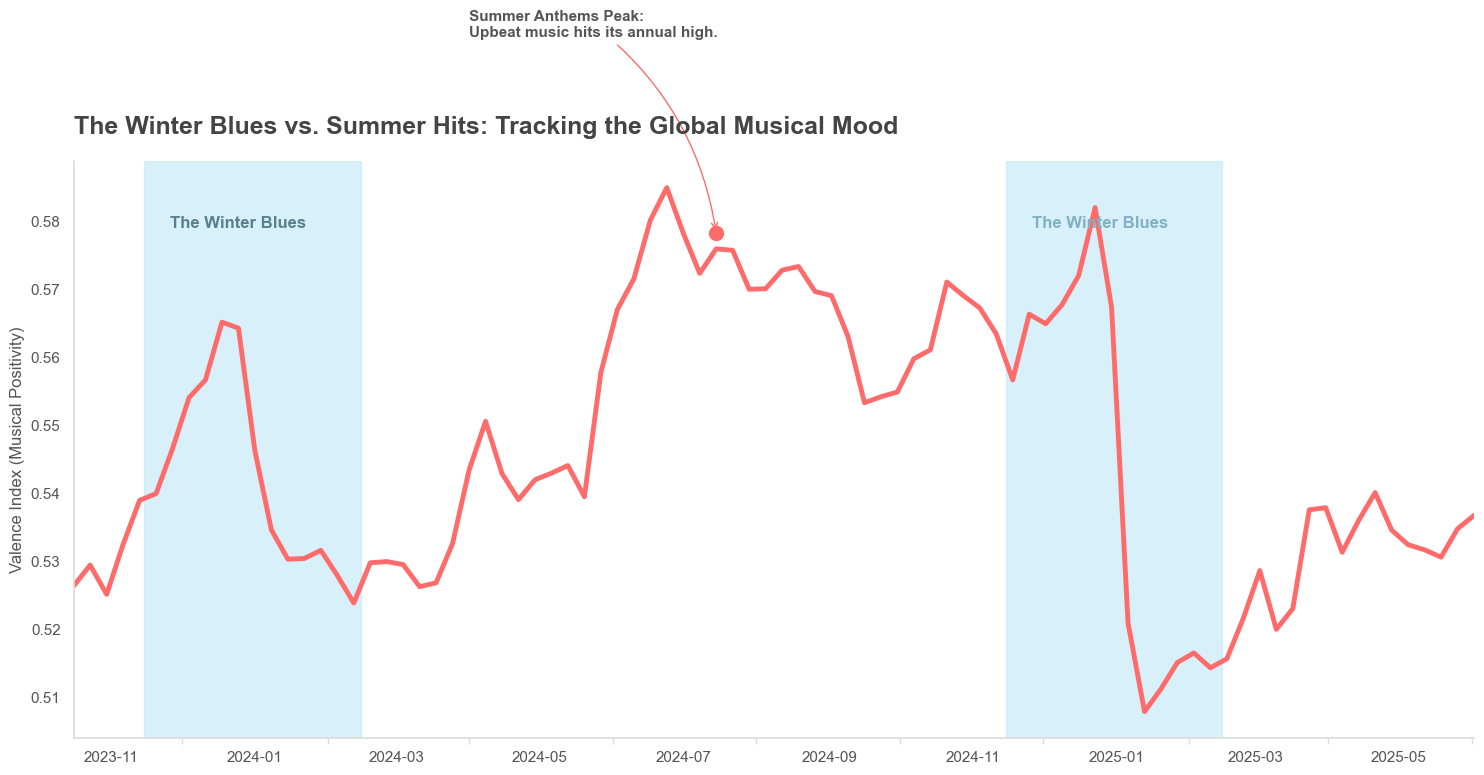

In [12]:
# 1) Förbered datan
df_plot = df_mood.iloc[:-1].copy()
df_plot['week'] = pd.to_datetime(df_plot['week'])

# 2) Grunsinställningar
sns.set_theme(style = "white")
fig, ax = plt.subplots(figsize=(15, 8))

# 3) Rita linje för Valence(Glädje) - Använder en varm färg för att representera sommar och energi
sns.lineplot(data=df_plot, x = 'week', y = 'avg_valence', color = '#FF6B6B', linewidth=3.5, ax=ax)


# ===============================================
# 4) STORYTELLING - Skuggar alla zoner för vinter
# Vinter-zones är isblåa zonerna i bakgrunden
# ===============================================
# Vinter nr 1: dec 2023 - feb 2024
ax.axvspan(pd.to_datetime('2023-11-15'), pd.to_datetime('2024-02-15'), color = '#c6ebf7', alpha = 0.7, zorder = 0)

# Vinter nr 2: dec 2024 - feb 2025
ax.axvspan(pd.to_datetime('2024-11-15'), pd.to_datetime('2025-02-15'), color = '#c6ebf7', alpha = 0.7, zorder = 0)

# Små texter uppe i hörnen av "vinter-zones"
plt.text(pd.to_datetime('2023-12-25'), df_plot['avg_valence'].max() * 0.99, 'The Winter Blues', 
         color='#59808f', fontsize=12, fontweight='bold', ha='center')
plt.text(pd.to_datetime('2024-12-25'), df_plot['avg_valence'].max() * 0.99, 'The Winter Blues', 
         color='#81b2c4', fontsize=12, fontweight='bold', ha='center')

# =============================
# 5) Annoteringar: Sommarglädje
# =============================
# Hittar peaken under sommaren 2024 i Juli
summer_24 = pd.to_datetime('2024-07-15')
y_summer = df_plot.loc[(df_plot['week'] >= '2024-07-01') & (df_plot['week'] <= '2024-07-31'), 'avg_valence'].max()

plt.scatter(summer_24, y_summer, color='#FF6B6B', s=100, zorder=5)
plt.annotate(
    "Summer Anthems Peak:\nUpbeat music hits its annual high.",
    xy=(summer_24, y_summer),
    xytext=(pd.to_datetime('2024-04-01'), y_summer * 1.05),
    arrowprops=dict(facecolor='#FF6B6B', edgecolor='#FF6B6B', arrowstyle="->", connectionstyle="arc3,rad=-0.2"),
    fontsize=11, color='#555555', fontweight='bold'
)


# 6) Decluttering, spines etc.
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#dddddd')
ax.spines['bottom'].set_color('#dddddd')

# 7) Ticks och marginalerna
ax.set_xlim(df_plot['week'].min(), df_plot['week'].max())
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.tick_params(axis='x', which='minor', bottom=True, colors='#dddddd', length=4, direction='out')
ax.tick_params(axis='both', which='major', colors = '#555555', length=6)
ax.tick_params(axis='y', colors='#555555')

# 8) Titel.
plt.title("The Winter Blues vs. Summer Hits: Tracking the Global Musical Mood", 
          fontsize=18, fontweight='bold', color='#444444', pad=20, loc='left')

plt.xlabel("")
plt.ylabel("Valence Index (Musical Positivity)", fontsize=12, color = '#555555')

plt.tight_layout()
plt.show()